### **1.Consumo di alcol per paese** 
Esegui un’**analisi esplorativa** focalizzata sul **consumo di alcol**.  
Analizza i seguenti aspetti:
* Visualizza i primi 10 paesi ordinati per total_litres_of_pure_alcohol (dal più alto)

* Calcola la media del consumo di birra, vino, e distillati

* Crea una nuova colonna alcohol_index che sia: `(beer_servings + wine_servings + spirit_servings) / 3`

* Trova il paese con il valore massimo di alcohol_index

* Filtra solo i paesi che consumano più di 100 birre all’anno

Crea un bar chart dei 10 paesi con più consumo totale (total_litres_of_pure_alcohol)

Crea un line plot con wine_servings ordinato per paese (usa sort_values)

Visualizza i primi 10 paesi ordinati per total_litres_of_pure_alcohol (dal più alto)
                country  beer_servings  spirit_servings  wine_servings  \
15              Belarus            142              373             42   
98            Lithuania            343              244             56   
3               Andorra            245              138            312   
68              Grenada            199              438             28   
45       Czech Republic            361              170            134   
61               France            127              151            370   
141  Russian Federation            247              326             73   
81              Ireland            313              118            165   
155            Slovakia            196              293            116   
99           Luxembourg            236              133            271   

     total_litres_of_pure_alcohol  
15                           14.4  
98                          

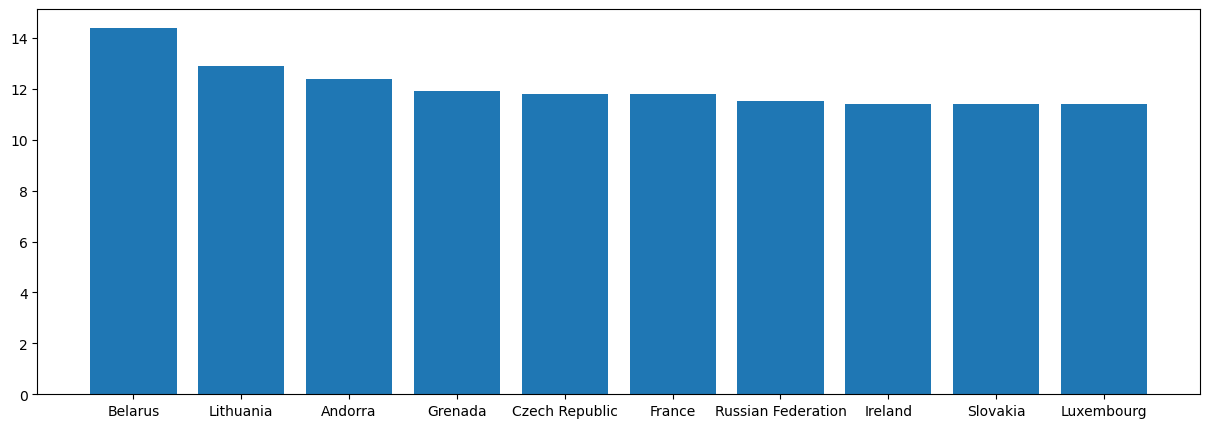

Crea un line plot con wine_servings ordinato per paese (usa sort_values)


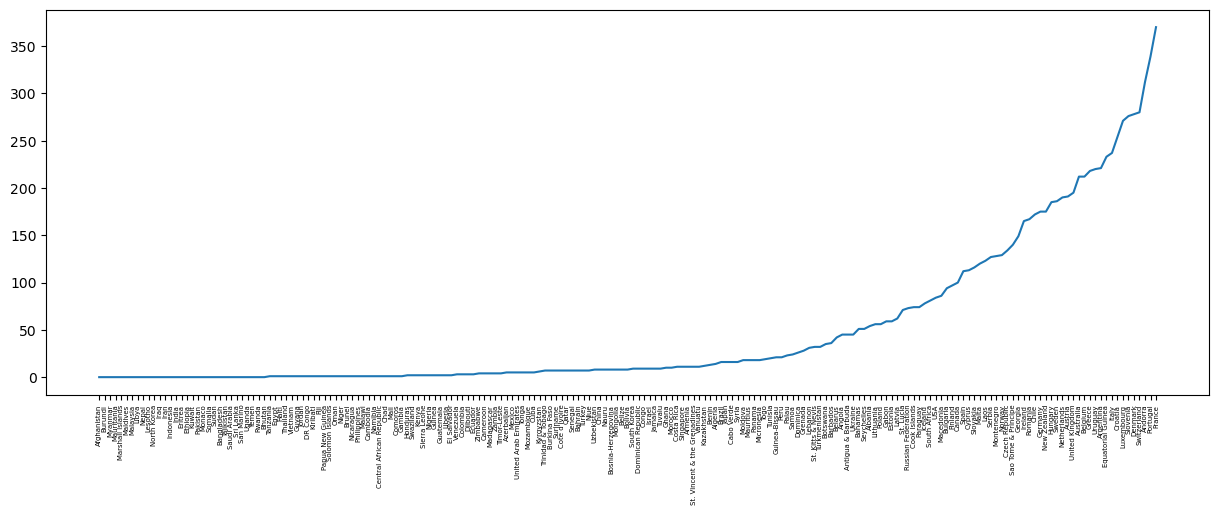

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("https://raw.githubusercontent.com/fivethirtyeight/data/master/alcohol-consumption/drinks.csv")
print("Visualizza i primi 10 paesi ordinati per total_litres_of_pure_alcohol (dal più alto)")
primi10PaesiConsumoAlcolico = df.sort_values(by="total_litres_of_pure_alcohol",ascending=False).head(10)
print(primi10PaesiConsumoAlcolico)

print("\n\nCalcola la media del consumo di birra, vino e distillati")
print(df[["beer_servings", "wine_servings", "spirit_servings"]].mean())

print("\nCrea una nuova colonna alcohol_index che sia: `(beer_servings + wine_servings + spirit_servings) / 3`")
df["alcohol_index"]=((df["beer_servings"] + df["wine_servings"] + df["spirit_servings"]) / 3)
print("Colonna creata\n\n")
print("Trova il paese con il valore massimo di alcohol_index")
print(df.loc[df["alcohol_index"].idxmax(),["country","alcohol_index"]])
#

print("\n\nFiltra solo i paesi che consumano più di 100 birre all’anno")
print(df[df["beer_servings"]>100])


print("Crea un bar chart dei 10 paesi con più consumo totale (total_litres_of_pure_alcohol)")
plt.figure(figsize=(15,5))
plt.bar(primi10PaesiConsumoAlcolico["country"],primi10PaesiConsumoAlcolico["total_litres_of_pure_alcohol"])
plt.show()
print("Crea un line plot con wine_servings ordinato per paese (usa sort_values)")

dfWineSorted=df.sort_values(by="wine_servings")
plt.figure(figsize=(15,5))
plt.plot(dfWineSorted["country"],dfWineSorted["wine_servings"])
plt.xticks(rotation=90,fontsize=5)
plt.show()




### **2.Analisi offerte di lavoro** 

Esegui un’**analisi esplorativa** focalizzata sui **lavori nel campo dei dati in ciascun paese**.  
Analizza i seguenti aspetti per ogni paese:

* Lo **stipendio medio annuale** (`salary_year_avg`)
* Il **numero totale di offerte di lavoro** (job count)
* L’intervallo degli stipendi: **valore minimo e massimo** (`min` / `max`)

Rappresenta graficamente lo stipendio medio (`salary_year_avg`) per `job_title_short` usando un grafico a barre orizzontali. Ordina i dati dallo stipendio più alto al più basso. Includi un titolo e le etichette per gli assi x e y.

In [ ]:
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

dataset = load_dataset("lukebarousse/data_jobs")
df = dataset["train"].to_pandas()

df_sorted = df.sort_values(by="salary_year_avg", ascending=False)

print(df.columns)

plt.figure(figsize=(10, 12))
plt.barh(df_sorted["job_title_short"], df_sorted["salary_year_avg"])
plt.xlabel("Stipendio medio all'anno")
plt.ylabel("Job Title")
plt.title("Stipendio medio per job_title_short ")
plt.show()

#ho avuto problemi nel download del dataset perché bloccato dalla rete. il codice non ho avuto modo di testarlo


'[Errno 11001] getaddrinfo failed' thrown while requesting HEAD https://huggingface.co/datasets/lukebarousse/data_jobs/resolve/ed776e5a0a8c40ea9d5efbd800772ae52e140f3e/data_jobs.py
Retrying in 1s [Retry 1/5].
Using the latest cached version of the dataset since lukebarousse/data_jobs couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at C:\Users\stefa\.cache\huggingface\datasets\lukebarousse___data_jobs\default\0.0.0\ed776e5a0a8c40ea9d5efbd800772ae52e140f3e (last modified on Tue Jun  2 03:19:58 2026).


Index(['job_title_short', 'job_title', 'job_location', 'job_via',
       'job_schedule_type', 'job_work_from_home', 'search_location',
       'job_posted_date', 'job_no_degree_mention', 'job_health_insurance',
       'job_country', 'salary_rate', 'salary_year_avg', 'salary_hour_avg',
       'company_name', 'job_skills', 'job_type_skills'],
      dtype='object')


KeyboardInterrupt: 

Error in callback <function _draw_all_if_interactive at 0x000001387DAA02C0> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

### **3. Analisi vendite (dataset tips)**

Esegui un’**analisi esplorativa** focalizzata sulle **vendite giornaliere**.  
Analizza i seguenti aspetti per ogni giorno (`day`):

* Il **conto medio** (`total_bill`)
* Il **numero totale di osservazioni** (conteggio delle righe)
* Il **valore minimo e massimo** del conto (`total_bill` → `min` / `max`)

* Crea una nuova colonna `conto_per_persona` che sia:  
  `total_bill / size`

* Trova il giorno con il **conto medio più alto**

Rappresenta graficamente il **conto medio (`total_bill`) per giorno** usando un **grafico a barre**.  
Ordina i dati dal valore più alto al più basso.  
Aggiungi titolo ed etichette agli assi.

Stats per ogni giorno:
            mean  count   min    max
day                                
Fri   17.151579     19  5.75  40.17
Sat   20.441379     87  3.07  50.81
Sun   21.410000     76  7.25  48.17
Thur  17.682742     62  7.51  43.11
   total_bill   tip     sex smoker  day    time  size  conto_per_persona
0       16.99  1.01  Female     No  Sun  Dinner     2           8.495000
1       10.34  1.66    Male     No  Sun  Dinner     3           3.446667
2       21.01  3.50    Male     No  Sun  Dinner     3           7.003333
3       23.68  3.31    Male     No  Sun  Dinner     2          11.840000
4       24.59  3.61  Female     No  Sun  Dinner     4           6.147500
Il giorno con il conto medio più alto è:  Sun


<BarContainer object of 4 artists>

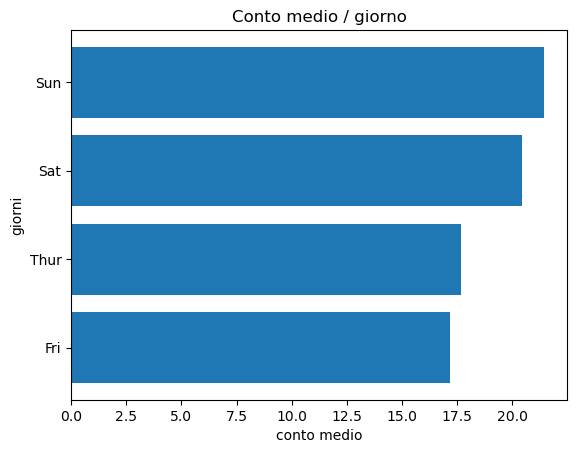

In [57]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
df = pd.read_csv(url)

df.head()
#generali
#print("Conto medio: ",df["total_bill"].mean())
#print("Il contegggio delle righe e': ", len(df))
#print("Range total_bill: ", df["total_bill"].min(), " - ", df["total_bill"].max())
#per ogni giorno: 

print("Stats per ogni giorno:\n",df.groupby("day")["total_bill"].agg(["mean","count","min","max"]))

df["conto_per_persona"] = df["total_bill"] / df["size"]

print(df.head())

mediaContoPerGiorno=df.groupby("day")["total_bill"].agg(["mean"])
df_media=mediaContoPerGiorno.reset_index()
df_media.columns = ["day","mean_total_bill"]
df_media=df_media.sort_values("mean_total_bill")

print("Il giorno con il conto medio più alto è: ",df_media.loc[df_media["mean_total_bill"].idxmax(),"day"])
plt.xlabel("conto medio")
plt.ylabel("giorni")
plt.title("Conto medio / giorno")
plt.barh(df_media["day"],df_media["mean_total_bill"])